# This notebook for understanding raw data before any preprocessing and cleaning

In [8]:
# Importing important libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import sys
import os
import sys
from pathlib import Path


In [9]:

# 1. Get the current working directory
current_dir = Path.cwd()
project_root = current_dir

# 2. Traverse upwards until we find the root directory (which contains 'src')
while not (project_root / 'src').exists() and project_root.parent != project_root:
    project_root = project_root.parent

# 3. Add the project root to the system path
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print(f"Project root successfully set to: {project_root}")


Project root successfully set to: d:\CreditRisk-ML\CreditRisk-ML


In [12]:
# loading raw data
from src.data.data_fetching.load_data import load_raw_data

train_data,test_data = load_raw_data()
if train_data is not None:
    print("\n--- Data successfully loaded into Notebook ---")
    print(f"Train shape: {train_data.shape}")
    display(train_data.head())
    print(f"Test shape: {test_data.shape}")
    display(test_data.head())


Loading training data from: D:\CreditRisk-ML\CreditRisk-ML\data\raw\training.csv
Loading testing data from: D:\CreditRisk-ML\CreditRisk-ML\data\raw\test.csv
Data loaded successfully!


--- Data successfully loaded into Notebook ---
Train shape: (150000, 12)


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


Test shape: (101503, 12)


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,NaN,0.885519,43,0,0.177513,5700.0,4,0,0,0,0.0
1,2,NaN,0.463295,57,0,0.527237,9141.0,15,0,4,0,2.0
2,3,NaN,0.043275,59,0,0.687648,5083.0,12,0,1,0,2.0
3,4,NaN,0.280308,38,1,0.925961,3200.0,7,0,2,0,0.0
4,5,NaN,1.000000,27,0,0.019917,3865.0,4,0,0,0,1.0


In [13]:
print(f"Train shape: {train_data.shape} Test shape: {test_data.shape}")

Train shape: (150000, 12) Test shape: (101503, 12)


In [14]:
train_data.dtypes

Unnamed: 0                                int64
SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object

In [15]:
test_data.dtypes

Unnamed: 0                                int64
SeriousDlqin2yrs                        float64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object

In [16]:
print(train_data.dtypes == test_data.dtypes)

Unnamed: 0                               True
SeriousDlqin2yrs                        False
RevolvingUtilizationOfUnsecuredLines     True
age                                      True
NumberOfTime30-59DaysPastDueNotWorse     True
DebtRatio                                True
MonthlyIncome                            True
NumberOfOpenCreditLinesAndLoans          True
NumberOfTimes90DaysLate                  True
NumberRealEstateLoansOrLines             True
NumberOfTime60-89DaysPastDueNotWorse     True
NumberOfDependents                       True
dtype: bool


In [18]:
train_data.describe()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [19]:
test_data.describe()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,101503.000000,0.0,101503.000000,101503.000000,101503.000000,101503.000000,8.140000e+04,101503.000000,101503.000000,101503.000000,101503.000000,98877.000000
mean,50752.000000,NaN,5.310000,52.405436,0.453770,344.475020,6.855036e+03,8.453514,0.296691,1.013074,0.270317,0.769046
std,29301.536524,NaN,196.156039,14.779756,4.538487,1632.595231,3.650860e+04,5.144100,4.515859,1.110253,4.503578,1.136778
min,1.000000,NaN,0.000000,21.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25376.500000,NaN,0.030131,41.000000,0.000000,0.173423,3.408000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,50752.000000,NaN,0.152586,52.000000,0.000000,0.364260,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,76127.500000,NaN,0.564225,63.000000,0.000000,0.851619,8.200000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,101503.000000,NaN,21821.000000,104.000000,98.000000,268326.000000,7.727000e+06,85.000000,98.000000,37.000000,98.000000,43.000000


In [59]:
train_data[train_data['NumberOfTime30-59DaysPastDueNotWorse']==1]

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
30,31,0,0.704074,28,1,0.155201,4200.0,8,0,0,0,0.0
37,38,0,1.000000,75,1,0.134078,3400.0,1,0,1,0,1.0
40,41,0,0.719985,41,1,0.539554,5700.0,14,0,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
149924,149925,1,0.673699,62,1,3653.000000,NaN,16,0,1,0,1.0
149938,149939,0,0.329479,35,1,0.339813,2571.0,7,0,1,0,1.0
149944,149945,0,0.291860,36,1,0.119287,24000.0,12,0,2,0,0.0
149961,149962,1,0.920107,31,1,0.176732,1125.0,4,1,0,0,0.0


In [32]:
train_data[train_data['RevolvingUtilizationOfUnsecuredLines'] == 0]

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
35,36,0,0.0,64,0,0.073539,11000.0,9,0,1,0,0.0
65,66,0,0.0,67,0,0.540984,3720.0,2,0,1,0,0.0
85,86,0,0.0,58,0,0.316145,4886.0,9,0,1,0,1.0
126,127,0,0.0,61,0,0.222660,3300.0,14,0,1,0,0.0
127,128,0,0.0,59,0,0.218854,19167.0,13,0,2,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
149926,149927,0,0.0,70,0,0.129249,5500.0,14,0,1,0,1.0
149930,149931,0,0.0,70,0,0.253990,3633.0,12,0,1,0,0.0
149933,149934,0,0.0,56,0,0.494101,5000.0,8,0,1,0,0.0
149960,149961,0,0.0,49,0,353.000000,NaN,2,0,0,0,0.0


In [33]:
train_data['SeriousDlqin2yrs'].value_counts()

SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

In [40]:
(train_data['age'] < 90).value_counts()

age
True     149313
False       687
Name: count, dtype: int64

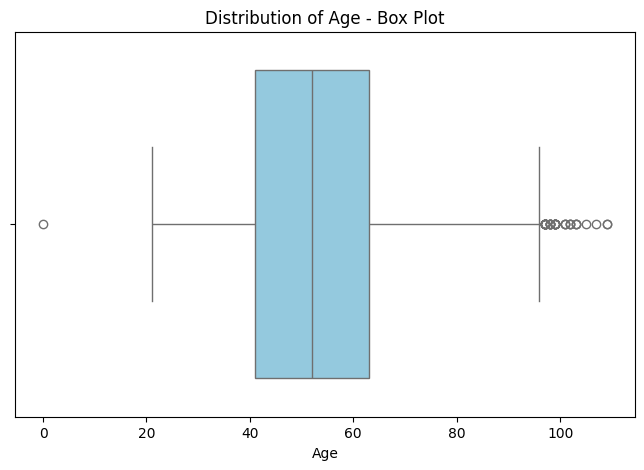

In [37]:
# 2. Set the size of the plot
plt.figure(figsize=(8, 5))

# 3. Create the box plot for the 'age' column
sns.boxplot(x=train_data['age'], color='skyblue')

# 4. Add title and labels for clarity
plt.title('Distribution of Age - Box Plot')
plt.xlabel('Age')

# 5. Display the plot
plt.show()

In [41]:
train_data.columns

Index(['Unnamed: 0', 'SeriousDlqin2yrs',
       'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='object')

In [66]:
outliers_impact = train_data[train_data['NumberOfTime30-59DaysPastDueNotWorse'] > 20].groupby('SeriousDlqin2yrs').size()
print(outliers_impact)

SeriousDlqin2yrs
0    122
1    147
dtype: int64


In [68]:
(train_data['SeriousDlqin2yrs'] == 1 ).value_counts()

SeriousDlqin2yrs
False    139974
True      10026
Name: count, dtype: int64

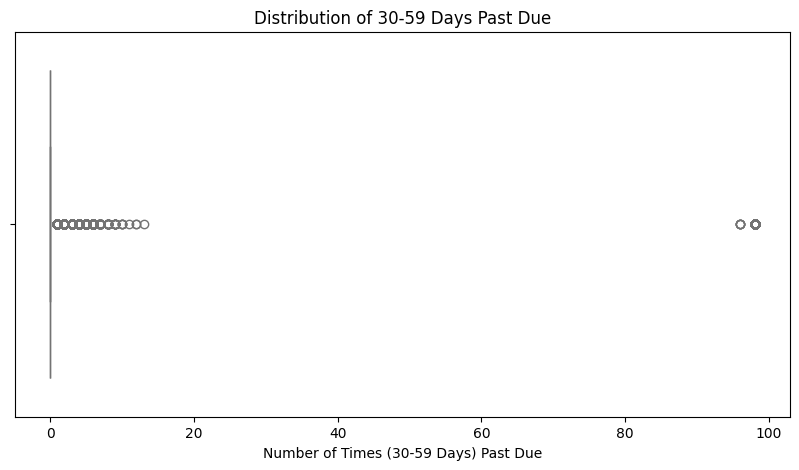

In [57]:
# 1. Set the size of the plot
plt.figure(figsize=(10, 5))

# 2. Create the box plot
sns.boxplot(x=train_data['NumberOfTime30-59DaysPastDueNotWorse'], color='lightgreen')

# 3. Add title and labels
plt.title('Distribution of 30-59 Days Past Due')
plt.xlabel('Number of Times (30-59 Days) Past Due')

# 4. Display the plot
plt.show()